In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on outage variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [2]:
#pulling standardized socioeconomic variables
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)

In [3]:
#Keeping derived calculations only
features_for_pca = [
    "total_outages",
    "mean_duration_hours",
    "median_duration_hours",
    "max_duration_hours",
    "total_duration_hours",
    "mean_customers_affected",
    "max_customers_affected",
    "total_customers_affected",
    "total_customer_minutes_out",
    "pct_outages_in_summer",
    "pct_outages_in_winter"
]

In [4]:
scaler = StandardScaler()

# RTP county FIPS codes
rtp_counties = ['063', '183', '135']  # Durham, Wake, Orange

# Ensure TRACT is a string
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

# Extract county FIPS (digits 3–5)
tract_outages['county_fips'] = tract_outages['TRACT'].str[2:5]

# Keep only RTP counties
tract_outages = tract_outages[
    tract_outages['county_fips'].isin(rtp_counties)
].copy()
 

In [5]:
# Separate features and ID
X = tract_outages.drop(columns=['TRACT'])  
X = X[features_for_pca] 
X = scaler.fit_transform(X[features_for_pca])
tract_ids = tract_outages['TRACT']     

## Scree Plot

To see how many PCs to keep

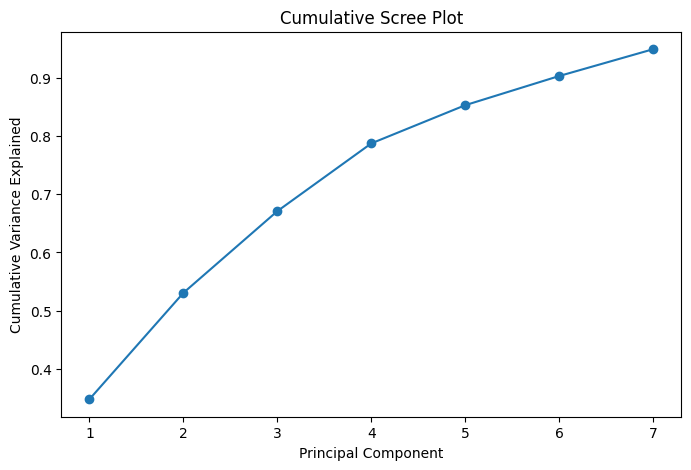

In [6]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

Planning on using 4 components

## Running PCA for 4 components

In [7]:
# Keeping first two principle components
pca = PCA(n_components=4)
pca_scores = pca.fit_transform(X)

In [8]:
pc_cols = ["PC1", "PC2", "PC3", "PC4"]
outages_tract_pca_scores = pd.DataFrame(pca_scores, columns=pc_cols)

# Add TRACT IDs back
outages_tract_pca_scores["TRACT"] = tract_ids.values

# Create PCA loadings dataframe
outages_tract_loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=pc_cols
)

outages_tract_loadings.to_csv("data_processed/outages_pca_results_RTP/outages_tract_loadings.csv", index=True)


PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3, PC4

tract_outages_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract outages axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, PC3, and PC4 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation:

PC1 — Overall Outage Exposure and System Burden

Dominant positive loadings

Total customer minutes out (+0.42)

Total customers affected (+0.42)

Total duration hours (+0.37)

Max customers affected (+0.38)

Total outages (+0.32)

Mean customers affected (+0.31)

Interpretation
PC1 is a pure magnitude component capturing overall outage severity and exposure. High values indicate places that experience:

More outages

Affect more customers

Accumulate more total outage time

This is the primary reliability burden axis.

Recommended title

PC1 — Overall Outage Burden

PC2 — Typical Outage Duration vs. Customer Reach

Dominant positive loadings

Mean duration (+0.50)

Median duration (+0.47)

Max duration (+0.36)

Dominant negative loadings

Mean customers affected (–0.33)

Total customers affected (–0.27)

Interpretation
This component contrasts:

Longer-lasting outages affecting fewer customers
vs.

Shorter outages affecting many customers

High PC2 values correspond to persistent, localized outages (e.g., feeder-level failures, rural lines).

Recommended title

PC2 — Localized, Long-Duration Outages

PC3 — Event-Driven vs. Chronic Outage Patterns

Dominant positive loadings

Total outages (+0.52)

Total duration (+0.41)

Winter outages (+0.33)

Dominant negative loadings

Summer outages (–0.40)

Mean customers affected (–0.37)

Interpretation
PC3 distinguishes frequent, seasonal (winter-driven), smaller-scale outages from summer-peaking, customer-intensive outages.

This often aligns with:

Ice / wind / cold-weather reliability issues vs.

Summer peak load or storm-driven failures

Recommended title

PC3 — Seasonal and Event-Driven Outage Stress

PC4 — Seasonal Polarity: Winter vs. Summer Risk

Dominant positive loadings

Winter outages (+0.59)

Median duration (+0.35)

Dominant negative loadings

Summer outages (–0.56)

Total outages (–0.24)

Interpretation
PC4 isolates seasonal dominance:

High values → winter-dominated outage profiles

Low values → summer-dominated outage profiles

This component is orthogonal to magnitude and captures climate sensitivity.

Recommended title

PC4 — Seasonal Outage Regime (Winter vs. Summer)

UPDATE

PC1 - High-Impact Medium Duration Outages
More positive means that tract has more total outages (not compared to PC3 though) that are of medium length, affects the most households, and has the most household * minutes out. Slight lean towards these outages happenign in the summer.

PC2 Long-Duration, Low-Reach Outages
More positive means that the tract has the longest outage durations, but they affect fewer people. Slight lean towards these outages happening in the summer.

PC3 Frequent Short Winter Outages
Higher ranking means more total outages, but they are short and don't necessarily impact many people. However, these are outages that happen more in the winter.

PC4 High-Impact Winter Outages
More positive means fewer total outages, but they are of medium length and impact more households, these outages happen much more in winter, most interesting in its seasonality componenet

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

We want to:

    • Cluster tracts based on PC1, PC2, PC3, PC4 scores
    • THEN examine socioeconomic metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which outage types disproportionately affect which communities?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

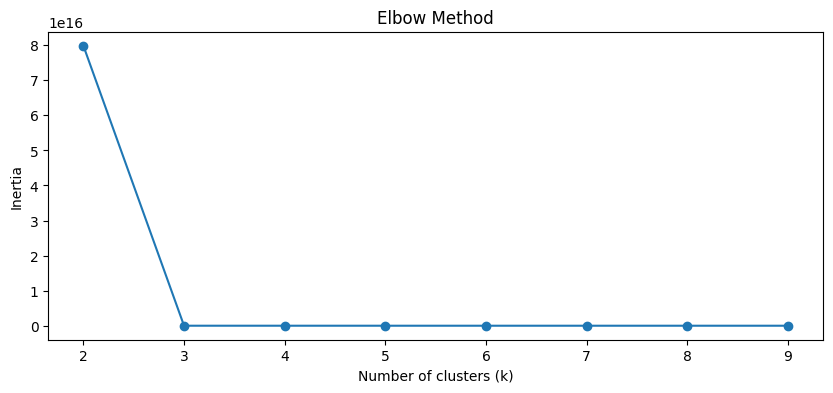

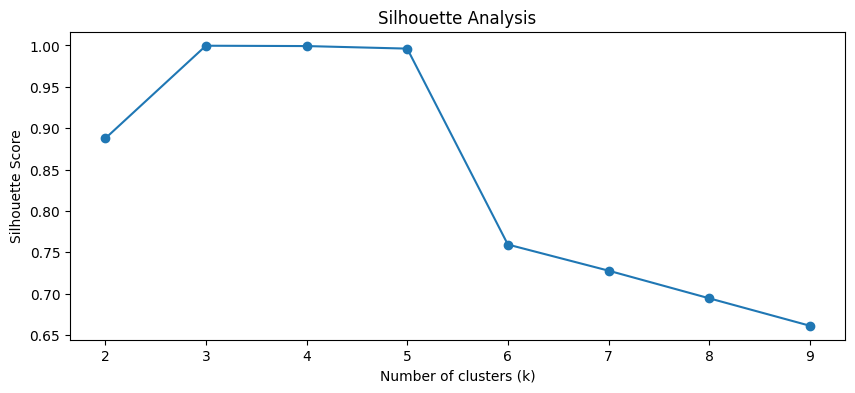

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(outages_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(outages_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [10]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
outages_tract_pca_scores['cluster'] = kmeans.fit_predict(outages_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [11]:
df = tract_outages.merge(outages_tract_pca_scores[['TRACT','cluster']], on='TRACT')

outages_cluster_profiles = df.groupby('cluster')[features_for_pca].mean()
outages_cluster_profiles.to_csv("data_processed/outages_pca_results_RTP/outages_cluster_profiles.csv", index=True)


Cluster 0: Lower-impact, shorter outages (baseline reliability)

Defining characteristics

Lowest total outages (≈ 111)

Shortest mean and median durations (≈ 1.65 / 1.02 hours)

Lowest max duration (≈ 10.4 hours)

Lowest total duration hours

Smallest customer impacts:

Lowest mean customers affected

Lowest max customers affected

Lowest total customer-minutes out

Lower summer share (≈ 48%)

Interpretation
This cluster represents relatively reliable areas. Outages occur, but they:

Are short

Affect fewer customers

Accumulate less total customer harm

These tracts likely have stronger infrastructure or redundancy, and outages tend to be localized and quickly resolved.

➡️ This is the low-burden / baseline reliability cluster.

Cluster 1: High customer-impact, frequent outages (system-wide exposure)

Defining characteristics

Highest total outages (≈ 142)

Moderately long durations

Highest customer exposure:

Highest mean customers affected

Highest max customers affected

Highest total customers affected

Highest total customer-minutes out

High summer outage share (≈ 52%)

Interpretation
Cluster 1 experiences frequent outages that affect many customers, even if durations are not the longest. The defining feature is scale:

Outages are system-wide rather than localized

Many households are affected per event

Total customer burden is the highest overall

These tracts may include dense urban or suburban load centers, where even moderate outages translate into large aggregate impacts.

➡️ This is the high exposure / system-wide impact cluster.

Cluster 2: Long-duration, severe outages with moderate frequency (chronic reliability stress)

Defining characteristics

Second-highest total outages (≈ 138)

Longest outages across all metrics:

Highest mean duration

Highest median duration

Highest max duration (≈ 19 hours)

Highest total duration hours

High customer impact, though less than Cluster 1

Highest summer dominance (≈ 59%)

Lowest winter outage share

Interpretation
Cluster 2 represents tracts with persistent, long-lasting outages. While outages may not affect as many customers per event as Cluster 1, they:

Last much longer

Accumulate substantial total outage time

Indicate structural or geographic vulnerability (e.g., rural feeders, storm exposure, slower restoration)

These are places where outages are harder to fix, not necessarily broader.

➡️ This is the chronic duration / infrastructure stress cluster.

UPDATE:

Cluster 0 - Low-impact, short duration
- lowest total households affected, and household-minutes out
- Shortest mean and median durations
- smallest customer exposure per outage
- weak seasonality but slightly more summer than winter outages

Cluster 1 - Long-Duration, High-Impact Outages (severe but localized)
- Fewer outages than cluster 2
- Much longer man and median durations
- Highest mean and max households affected
- high total household-minutes out

Cluster 2 - High frquency, high exposure (recurrent system stress events)
- highest-stress cluster
- highest total outages
- longest total outage duration
- high total households affected
- Strong summer concentration

## Identify standout tracts directly using PCA scores and distances

### Identify Outliers Using PCA Distance

In [12]:
pc_df = outages_tract_pca_scores[['PC1','PC2','PC3','PC4']].copy()
pc_df['TRACT'] = outages_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2 + pc_df['PC4']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,PC4,TRACT,distance
82,12.538348,-0.316360,1.606184,3.388522,37135011103,13.090919
37,10.956187,-4.835984,-0.906718,1.156539,37063001809,12.065840
310,-4.343772,-4.030724,4.904770,6.729232,37183054206,10.220294
179,5.125308,0.188408,4.885549,-3.365700,37183053009,7.842244
302,5.962263,-4.265047,-2.599431,0.225999,37183054115,7.781216
86,1.746967,7.055169,-2.235358,0.668158,37135011107,7.633516
54,5.150760,-2.937106,-4.301905,1.885093,37063002029,7.564184
298,4.036556,-3.075821,-4.198056,3.095397,37183054111,7.277336
4,5.693321,-2.749443,-3.024664,1.411232,37063000302,7.149371
184,4.668304,-1.666716,4.866885,-0.581580,37183053109,6.971069


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top, then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

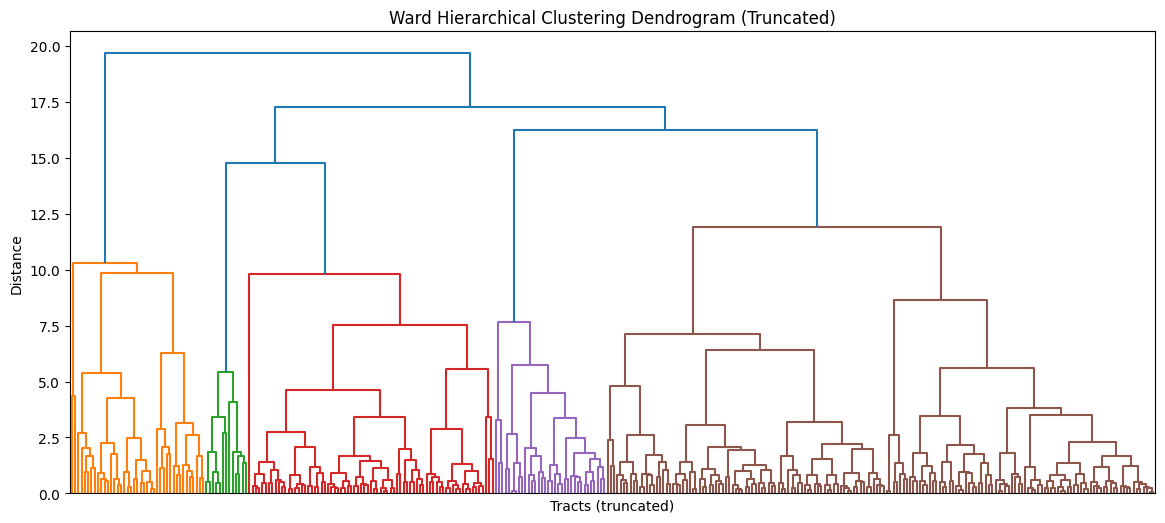

In [14]:
# Use the PCA scores for clustering
X = outages_tract_pca_scores[['PC1', 'PC2', 'PC3','PC4']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = outages_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

this dendrogram supports k = 4

k = 3 would merge two meaningfully distinct outage regimes

k = 4 is defensible if you can interpret all four clusters

### Map PCs or SES variables directly

Map PC1–PC4

In [15]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID'].str[:11]  
tract_geo = tract_geo.to_crs(epsg=4326)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3','PC4','cluster'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/outages_pca_results_RTP/outages_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


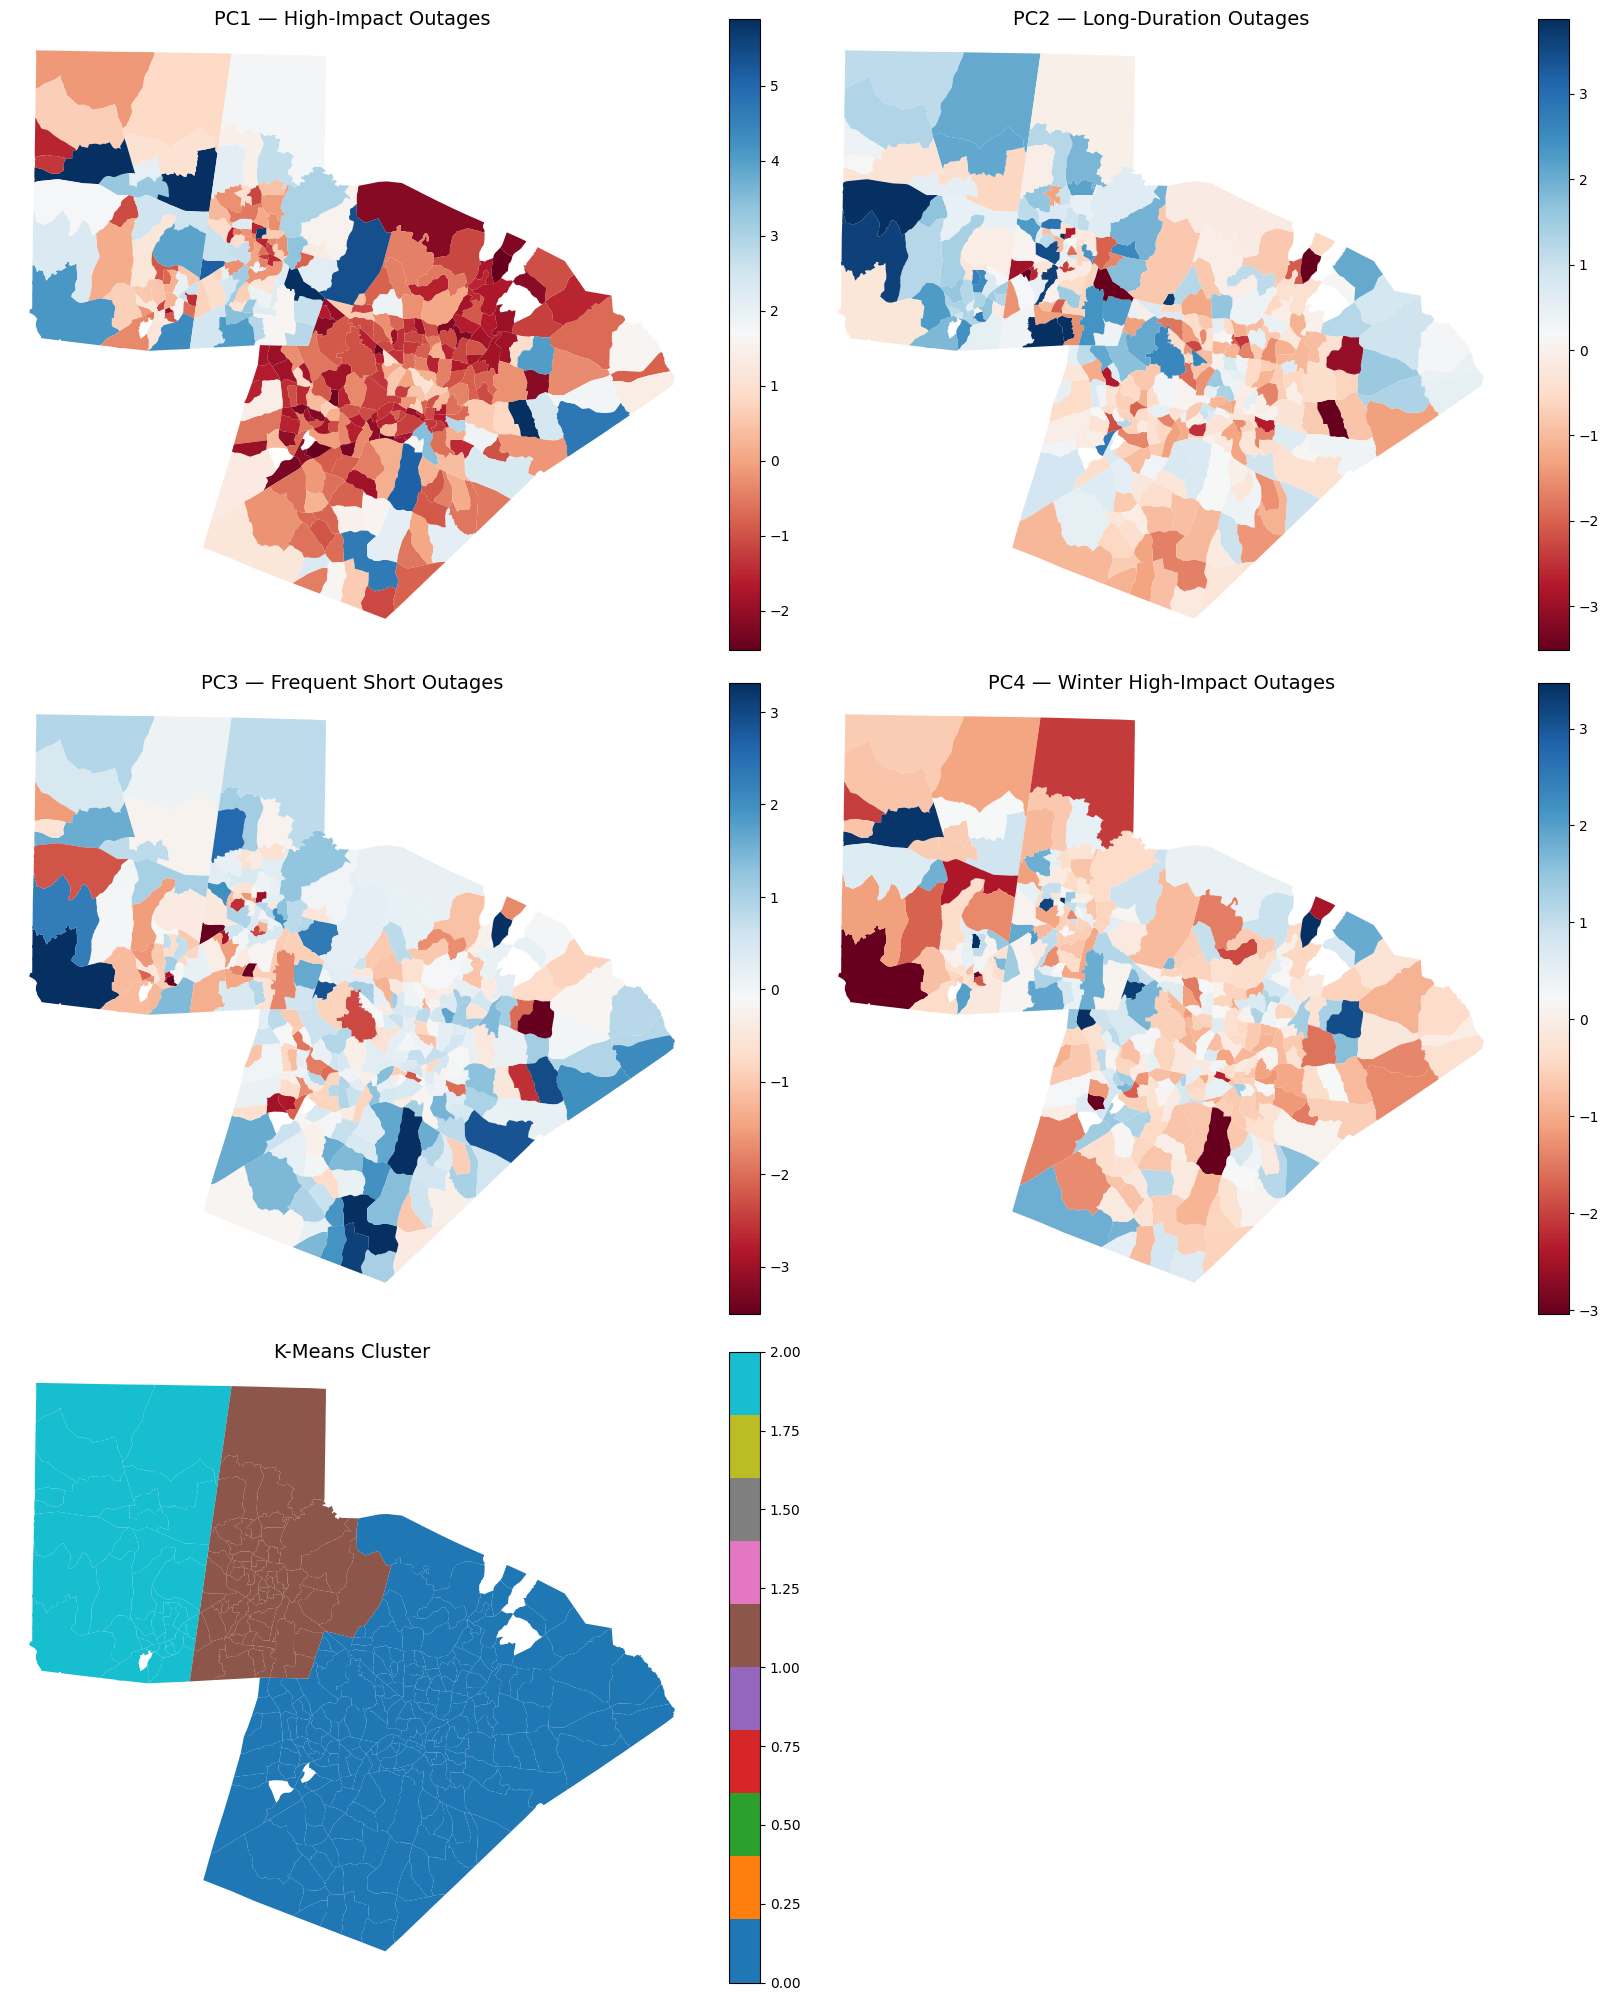

In [16]:
gdf['cluster'] = gdf['cluster'].astype(int)

variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — High-Impact Outages', 
    'PC2 — Long-Duration Outages', 
    'PC3 — Frequent Short Outages', 
    'PC4 — Winter High-Impact Outages',
    'K-Means Cluster'
]

# compute global bounds and add pad so all subplots show the same full area
xmin, ymin, xmax, ymax = gdf.total_bounds
# fallback if bounds are degenerate / not finite
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)
pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)
global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

fig, axes = plt.subplots(3, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]

    # skip if no geometries
    if gdf.geometry.is_empty.all() or gdf.geometry.isnull().all():
        ax.text(0.5, 0.5, "No geometries to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        gdf.plot(
            column='cluster',
            ax=ax,
            cmap='tab10',
            legend=True,
            linewidth=0,
            edgecolor='none',
            missing_kwds={"color": "lightgrey"}
        )

    else:
        # robust vmin/vmax
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()
        if col.empty:
            # fall back to greys if column missing
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)
            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()
            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            gdf.plot(
                column=var,
                ax=ax,
                cmap='RdBu',
                legend=True,
                vmin=vmin,
                vmax=vmax,
                linewidth=0,
                edgecolor='none',
                missing_kwds={"color": "lightgrey"}
            )

    # force same geographic extent so the full map displays in every subplot
    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)

    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

# hide the unused 6th plot (if present)
if len(axes) > len(variables):
    axes[len(variables)].set_visible(False)

plt.savefig(
    'data_processed/outages_pca_results_RTP/rtp_pca_maps.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Merge with socioeconomic + weather summaries (tract)

I have:
- tract_socioeconomic_unscaled
- tract_weather

Which are summaries of socioeconomics and weather for each tract.

This will help compute:
- Socioeconomic metrics per cluster
- Weather exposure per cluster

In [17]:
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str)
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']].merge(
    tract_socioeconomic, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
).merge(
    tract_outages, on = 'TRACT', how = 'left'
)


In [18]:
#DEFINING METRICS TO SUMMARIZE (from tract_socioeconomic and tract_weather)
socioeconomic_metrics = [
    'total_population',
    'median_household_income',
    'pct_below_50pct_poverty',
    'pct_no_vehicle',
    'pct_renters_cost_burdened',
    'pct_over65',
    'pct_with_disability',
    'pct_nonwhite'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days'
]

outage_metrics = [
    'total_outages', 'mean_duration_hours',
    'median_duration_hours', 'max_duration_hours', 'total_duration_hours',
    'mean_customers_affected', 'max_customers_affected',
    'total_customers_affected', 'total_customer_minutes_out',
    'pct_outages_in_summer', 'pct_outages_in_winter'
]

#keeping metrics that exist
metrics = [m for m in (socioeconomic_metrics + weather_metrics + outage_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('cluster')

In [19]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [20]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each cluster for a small set of key metrics:
key_metrics = socioeconomic_metrics + weather_metrics
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False]).head(50)

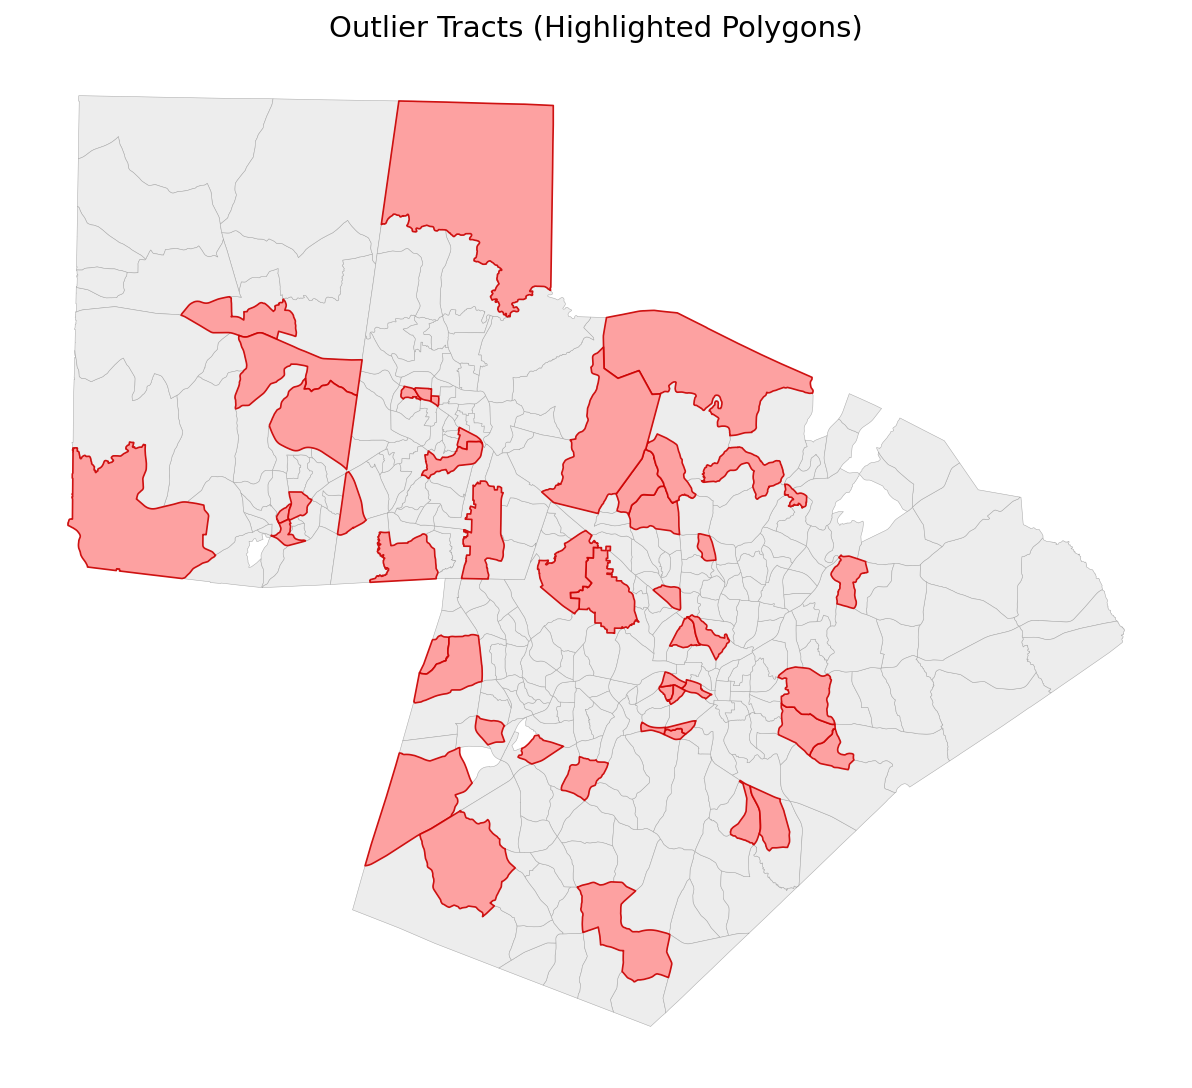

In [21]:
#gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
#outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

plt.savefig(
    'data_processed/outages_pca_results_RTP/outlier_tracts_static_map_polygons_only_outages_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/outages_pca_results_RTP/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/outages_pca_results_RTP/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/outages_pca_results_RTP/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


In [23]:
cluster_summary.columns

Index(['cluster', 'total_population_mean', 'total_population_median',
       'total_population_std', 'total_population_count',
       'median_household_income_mean', 'median_household_income_median',
       'median_household_income_std', 'median_household_income_count',
       'pct_below_50pct_poverty_mean', 'pct_below_50pct_poverty_median',
       'pct_below_50pct_poverty_std', 'pct_below_50pct_poverty_count',
       'pct_no_vehicle_mean', 'pct_no_vehicle_median', 'pct_no_vehicle_std',
       'pct_no_vehicle_count', 'pct_renters_cost_burdened_mean',
       'pct_renters_cost_burdened_median', 'pct_renters_cost_burdened_std',
       'pct_renters_cost_burdened_count', 'pct_over65_mean',
       'pct_over65_median', 'pct_over65_std', 'pct_over65_count',
       'pct_with_disability_mean', 'pct_with_disability_median',
       'pct_with_disability_std', 'pct_with_disability_count',
       'pct_nonwhite_mean', 'pct_nonwhite_median', 'pct_nonwhite_std',
       'pct_nonwhite_count', 'max_gust_du

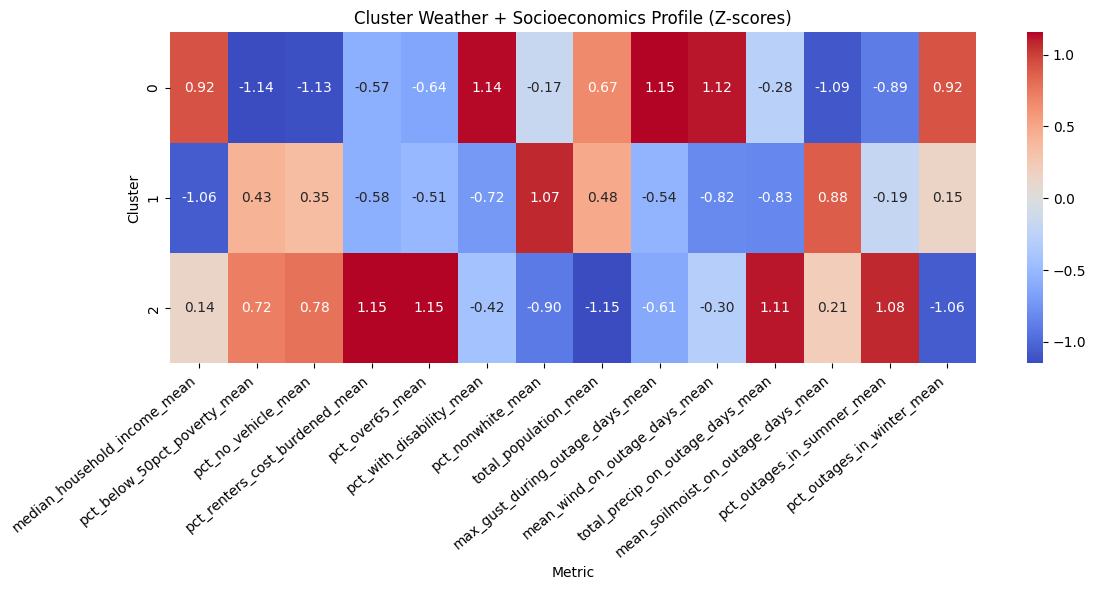

In [25]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'median_household_income_mean',
    'pct_below_50pct_poverty_mean',
    'pct_no_vehicle_mean',
    'pct_renters_cost_burdened_mean',
    'pct_over65_mean',
    'pct_with_disability_mean',
    'pct_nonwhite_mean',
    'total_population_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
    'pct_outages_in_summer_mean',
    'pct_outages_in_winter_mean'
    
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

heatmap_data = cluster_summary_std.set_index('cluster')[cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Socioeconomics Profile (Z-scores)")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

plt.savefig(
    'data_processed/outages_pca_results_RTP/heat_map_cluster_weather_socioeconomics.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()